# Political Speeches Topic Modeling & Dashboard

**Objective**: Analyze political speeches by Modi and Kharge using topic modeling to understand how their discourse themes evolve over time, and compare/contrast their rhetorical focus areas.

## Pipeline Overview
1. **Data Loading & Inspection** — Load CSV, handle missing values, parse dates
2. **Text Preprocessing & Feature Engineering** — Clean text, lemmatize, build TF-IDF & Count features
3. **Topic Modeling** — Evaluate LDA, NMF, LSA across multiple topic counts; select best via coherence
4. **Speaker Classification** — Train classifiers to validate that topics capture speaker-differentiating signals
5. **Model Persistence** — Save best topic model and vectorizer
6. **Visualization & Dashboard** — Temporal topic evolution, Venn diagram, interactive Dash dashboard

## 1. Environment Setup & Imports

In [21]:
# Install required packages
%pip install -q pandas numpy matplotlib seaborn wordcloud scikit-learn plotly nbformat ipykernel \
    matplotlib-venn joblib nltk dash dash-bootstrap-components gensim pyLDAvis

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import io
import base64
import warnings
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
from matplotlib_venn import venn2

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score
)
from sklearn.pipeline import Pipeline

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('All imports successful.')

All imports successful.


## 2. Data Loading & Inspection

In [23]:
# Load the dataset
df_raw = pd.read_csv('political_speeches (1).csv', encoding='utf-8-sig')

print(f"Raw dataset shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nSpeaker distribution:\n{df_raw['Speaker'].value_counts()}")
df_raw.head(3)

Raw dataset shape: (413, 8)

Columns: ['Speaker', 'Headline', 'Summary', 'Author', 'News Source', 'Published', 'Tags', 'URL']

Missing values:
Speaker          0
Headline         0
Summary          0
Author         413
News Source      0
Published        0
Tags           409
URL              0
dtype: int64

Speaker distribution:
Speaker
Modi      302
Kharge    111
Name: count, dtype: int64


,Speaker,Headline,Summary,Author,News Source,Published,Tags,URL
0,Modi,Two Odisha achievers find mention in PM Modi's...,Two Odisha achievers find mention in PM Modi's...,NaN,The Hans India,2026-03-29 11:08,NaN,https://news.google.com/rss/articles/CBMi1AFBV...
1,Modi,PM Modi addresses 132nd episode of Mann ki Baa...,PM Modi addresses 132nd episode of Mann ki Baa...,NaN,opindia.com,2026-03-29 10:57,NaN,https://news.google.com/rss/articles/CBMilAFBV...
2,Modi,"‘Honoured, motivated and proud’: Sambalpur fis...","‘Honoured, motivated and proud’: Sambalpur fis...",NaN,The Hans India,2026-03-29 10:50,NaN,https://news.google.com/rss/articles/CBMizgFBV...


In [24]:
# Data Cleaning
# Drop rows missing the key fields we need: Summary (text for modeling), Speaker, Published (for temporal analysis)
df = df_raw.dropna(subset=['Summary', 'Speaker', 'Published']).copy()

# Parse dates
df['Published'] = pd.to_datetime(df['Published'], errors='coerce')
df = df.dropna(subset=['Published'])

# Create time features for temporal analysis
df['YearMonth'] = df['Published'].dt.to_period('M').astype(str)
df['Month'] = df['Published'].dt.month_name()
df['Week'] = df['Published'].dt.isocalendar().week.astype(int)

# Combine Headline + Summary for richer text (Headline often has unique keywords)
df['Full_Text'] = df['Headline'].fillna('') + ' ' + df['Summary'].fillna('')

print(f"Clean dataset shape: {df.shape}")
print(f"Date range: {df['Published'].min().date()} to {df['Published'].max().date()}")
print(f"\nMonthly distribution:")
print(df.groupby(['YearMonth', 'Speaker']).size().unstack(fill_value=0))

Clean dataset shape: (413, 12)
Date range: 2025-10-31 to 2026-03-29

Monthly distribution:
Speaker    Kharge  Modi
YearMonth              
2025-10         2     1
2025-11         9    15
2025-12        27    19
2026-01        12    16
2026-02        40    73
2026-03        21   178


## 3. Text Preprocessing & Feature Engineering

**Strategy**: We combine Headline + Summary for richer signal, then apply:
- Lowercase, remove URLs/mentions/special chars
- Tokenize and lemmatize
- Remove English stopwords + domain-specific political stopwords (names, common filler words)
- Keep only tokens of length >= 3 to remove noise

In [25]:
# Build comprehensive stopword set
stop_words = set(stopwords.words('english'))

# Domain-specific stopwords: speaker names, party names, generic political terms
# that appear in almost every article and don't help differentiate topics
political_stopwords = {
    # Speaker names & titles (these dominate TF-IDF but don't define topics)
    'modi', 'narendra', 'kharge', 'mallikarjun', 'rahul', 'gandhi', 'pm', 'prime',
    # Party names (we want topics, not party labels)
    'bjp', 'congress', 'aap', 'nda', 'india', 'upa',
    # Generic political terms present in nearly all articles
    'said', 'says', 'also', 'would', 'could', 'one', 'two', 'new', 'news',
    'party', 'government', 'minister', 'leader', 'president', 'national',
    'country', 'people', 'state', 'political', 'politics',
    # News source artifacts
    'hindu', 'times', 'ndtv', 'ani', 'pti', 'report', 'source', 'gallery',
    'social', 'xyz', 'msn', 'watch', 'video', 'read', 'click', 'share',
    'get', 'know', 'latest', 'update', 'today', 'yesterday'
}
stop_words.update(political_stopwords)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenize, lemmatize text for topic modeling."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove @mentions and #hashtags
    text = re.sub(r'[@#]\w+', '', text)
    
    # Remove special characters, digits, punctuation — keep only letters & spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Lemmatize, remove stopwords, keep tokens >= 3 chars
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) >= 3
    ]
    
    return ' '.join(tokens)

# Apply preprocessing
df['Clean_Text'] = df['Full_Text'].apply(preprocess_text)

# Remove rows where cleaning produced empty text
df = df[df['Clean_Text'].str.strip().str.len() > 0].copy()

# Feature: text length (can indicate speech complexity)
df['Text_Length'] = df['Clean_Text'].str.split().str.len()

print(f"Dataset after preprocessing: {df.shape[0]} records")
print(f"\nAvg tokens per document: {df['Text_Length'].mean():.1f}")
print(f"\nSample cleaned text (Modi):")
print(df[df['Speaker']=='Modi']['Clean_Text'].iloc[0][:200])
print(f"\nSample cleaned text (Kharge):")
print(df[df['Speaker']=='Kharge']['Clean_Text'].iloc[0][:200])

Dataset after preprocessing: 413 records

Avg tokens per document: 18.1

Sample cleaned text (Modi):
odisha achiever find mention mann baat majhi express gratitude han odisha achiever find mention mann baat majhi express gratitude han

Sample cleaned text (Kharge):
chief release assam poll manifesto lakhimpur tomorrow northeast chief release assam poll manifesto lakhimpur tomorrow northeast


## 4. Exploratory Data Analysis

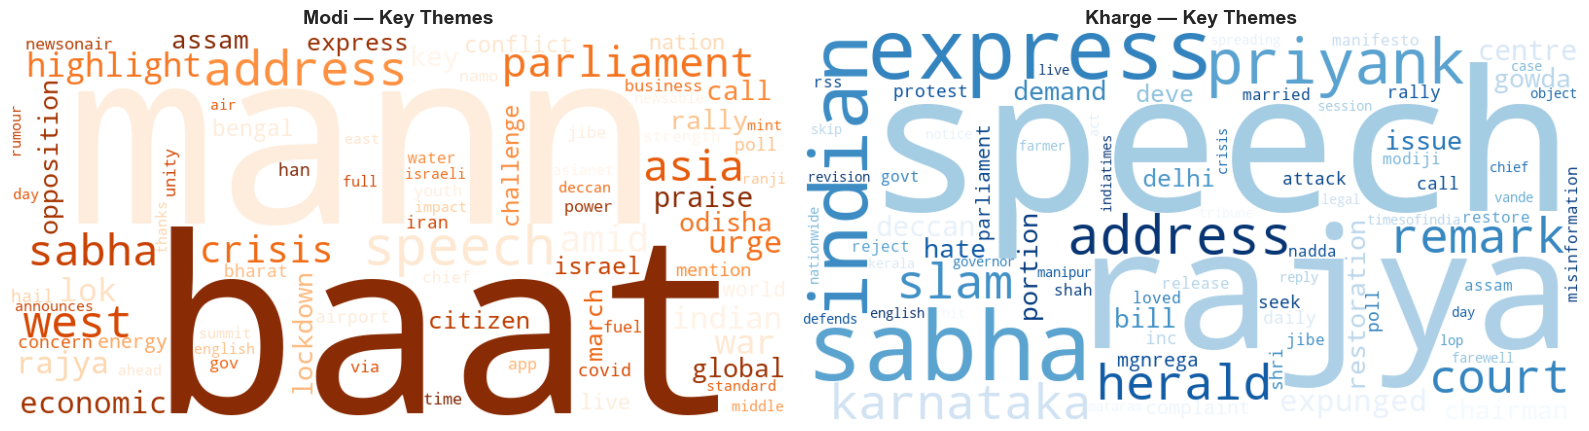

Word clouds saved.


In [26]:
# Word Clouds for each speaker
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, speaker, color in zip(axes, ['Modi', 'Kharge'], ['Oranges', 'Blues']):
    text = ' '.join(df[df['Speaker'] == speaker]['Clean_Text'])
    wc = WordCloud(
        width=800, height=400, background_color='white',
        colormap=color, collocations=False, max_words=80
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{speaker} — Key Themes', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds saved.")

In [27]:
# Distribution of articles over time by speaker
temporal_counts = df.groupby(['YearMonth', 'Speaker']).size().reset_index(name='Count')

fig = px.bar(
    temporal_counts, x='YearMonth', y='Count', color='Speaker',
    barmode='group', title='Article Volume Over Time by Speaker',
    color_discrete_map={'Modi': '#FF6B35', 'Kharge': '#004E89'}
)
fig.update_layout(xaxis_title='Month', yaxis_title='Number of Articles')
fig.show()

## 5. Feature Extraction (Vectorization)

We build two feature matrices:
- **TF-IDF** — Best for NMF, LSA, and classification (continuous weights penalize common terms)
- **Count (BoW)** — Best for LDA (LDA's generative model assumes integer word counts)

We use `max_df=0.85` to ignore terms in >85% of docs (too common), `min_df=3` to ignore very rare terms (noise), and bigrams to capture multi-word political phrases.

In [28]:
# TF-IDF Vectorizer — for NMF, LSA, and classification
tfidf_vec = TfidfVectorizer(
    max_df=0.85,        # Ignore terms appearing in >85% of docs
    min_df=3,            # Ignore terms appearing in <3 docs
    max_features=1500,   # Vocabulary cap
    ngram_range=(1, 2),  # Unigrams + bigrams for phrase capture
    sublinear_tf=True    # Apply log normalization to TF (reduces impact of high-frequency terms)
)
X_tfidf = tfidf_vec.fit_transform(df['Clean_Text'])

# Count Vectorizer — for LDA
count_vec = CountVectorizer(
    max_df=0.85,
    min_df=3,
    max_features=1500,
    ngram_range=(1, 2)
)
X_count = count_vec.fit_transform(df['Clean_Text'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Count matrix shape: {X_count.shape}")
print(f"Vocabulary size: {len(tfidf_vec.get_feature_names_out())} features")
print(f"\nSample features: {list(tfidf_vec.get_feature_names_out()[:20])}")

TF-IDF matrix shape: (413, 462)
Count matrix shape: (413, 462)
Vocabulary size: 462 features

Sample features: ['abp', 'abp live', 'accuses', 'across', 'act', 'address', 'address assam', 'address episode', 'address gathering', 'address parliament', 'address west', 'adjourned', 'adjourned amid', 'ahead', 'air', 'airport', 'amid', 'amid iran', 'amid opposition', 'amid west']


## 6. Topic Model Evaluation & Selection

### Why multiple models?
- **LDA (Latent Dirichlet Allocation)**: Probabilistic generative model. Best on count data. Produces interpretable topic-word distributions.
- **NMF (Non-negative Matrix Factorization)**: Matrix decomposition that tends to produce more coherent, specific topics on TF-IDF data.
- **LSA/SVD (Latent Semantic Analysis)**: Linear algebra approach. Fast but topics can mix positive/negative weights, making interpretation harder.

### Evaluation metrics:
- **Topic Coherence (UMass)**: Measures how frequently the top words in a topic co-occur. Higher (less negative) = better.
- **Silhouette Score**: After assigning each document to its dominant topic, measures cluster separation. Higher = topics are more distinct.
- We test k=4,5,6,7,8 topics for each model to find the optimal number.

### Avoiding overfitting:
- We cap vocabulary at 1500 features
- We use `max_df`/`min_df` to filter noise
- We evaluate coherence (not just fit) to ensure topics are meaningful, not just statistically optimal

In [29]:
def compute_umass_coherence(model, X, feature_names, top_n=10):
    """
    Compute UMass coherence score for a topic model.
    
    UMass coherence measures how often the top words in a topic co-occur
    in the same documents. It uses log-conditional probability:
    C = sum over pairs (wi, wj): log( (D(wi,wj) + 1) / D(wj) )
    
    Higher (less negative) values = more coherent topics.
    """
    # Convert to binary document-term matrix for co-occurrence
    X_binary = (X > 0).astype(int)
    doc_freq = np.array(X_binary.sum(axis=0)).flatten()  # How many docs contain each word
    
    # Co-occurrence matrix (word pairs appearing in same doc)
    co_occur = (X_binary.T @ X_binary).toarray()
    
    coherence_scores = []
    for topic in model.components_:
        top_word_indices = topic.argsort()[-top_n:][::-1]
        topic_coherence = 0
        n_pairs = 0
        for i in range(1, len(top_word_indices)):
            for j in range(i):
                wi = top_word_indices[i]
                wj = top_word_indices[j]
                # UMass formula: log( (co-occurrence + 1) / freq(wj) )
                topic_coherence += np.log((co_occur[wi, wj] + 1) / (doc_freq[wj] + 1))
                n_pairs += 1
        coherence_scores.append(topic_coherence / n_pairs if n_pairs > 0 else 0)
    
    return np.mean(coherence_scores)


def evaluate_topic_models(X_tfidf, X_count, tfidf_names, count_names, topic_range=range(4, 9)):
    """
    Evaluate LDA, NMF, and LSA across different topic counts.
    Returns a results DataFrame and the best model.
    """
    results = []
    all_models = {}
    
    for k in topic_range:
        print(f"\n--- Evaluating k={k} topics ---")
        
        # LDA on Count matrix (its natural input)
        lda = LatentDirichletAllocation(
            n_components=k, max_iter=30, learning_method='online',
            random_state=42, n_jobs=-1,
            doc_topic_prior=0.1,   # Sparse document-topic distribution
            topic_word_prior=0.01  # Sparse topic-word distribution
        )
        lda.fit(X_count)
        lda_topics = lda.transform(X_count)
        lda_labels = lda_topics.argmax(axis=1)
        
        lda_coherence = compute_umass_coherence(lda, X_count, count_names)
        lda_silhouette = silhouette_score(X_count, lda_labels) if len(set(lda_labels)) > 1 else -1
        lda_perplexity = lda.perplexity(X_count)
        
        results.append({
            'Model': 'LDA', 'K': k, 'Coherence': lda_coherence,
            'Silhouette': lda_silhouette, 'Perplexity': lda_perplexity
        })
        all_models[f'LDA_k{k}'] = lda
        print(f"  LDA:  coherence={lda_coherence:.4f}, silhouette={lda_silhouette:.4f}, perplexity={lda_perplexity:.1f}")
        
        # NMF on TF-IDF matrix (its natural input)
        nmf = NMF(n_components=k, max_iter=300, random_state=42)
        nmf.fit(X_tfidf)
        nmf_topics = nmf.transform(X_tfidf)
        nmf_labels = nmf_topics.argmax(axis=1)
        
        nmf_coherence = compute_umass_coherence(nmf, X_tfidf, tfidf_names)
        nmf_silhouette = silhouette_score(X_tfidf, nmf_labels) if len(set(nmf_labels)) > 1 else -1
        
        results.append({
            'Model': 'NMF', 'K': k, 'Coherence': nmf_coherence,
            'Silhouette': nmf_silhouette, 'Perplexity': np.nan
        })
        all_models[f'NMF_k{k}'] = nmf
        print(f"  NMF:  coherence={nmf_coherence:.4f}, silhouette={nmf_silhouette:.4f}")
        
        # LSA (TruncatedSVD) on TF-IDF
        lsa = TruncatedSVD(n_components=k, random_state=42, n_iter=20)
        lsa.fit(X_tfidf)
        lsa_topics = lsa.transform(X_tfidf)
        lsa_labels = np.abs(lsa_topics).argmax(axis=1)  # abs because SVD can have negative weights
        
        lsa_coherence = compute_umass_coherence(lsa, X_tfidf, tfidf_names)
        lsa_silhouette = silhouette_score(X_tfidf, lsa_labels) if len(set(lsa_labels)) > 1 else -1
        lsa_variance = lsa.explained_variance_ratio_.sum()
        
        results.append({
            'Model': 'LSA', 'K': k, 'Coherence': lsa_coherence,
            'Silhouette': lsa_silhouette, 'Perplexity': np.nan
        })
        all_models[f'LSA_k{k}'] = lsa
        print(f"  LSA:  coherence={lsa_coherence:.4f}, silhouette={lsa_silhouette:.4f}, var_explained={lsa_variance:.3f}")
    
    return pd.DataFrame(results), all_models


# Run evaluation
tfidf_names = tfidf_vec.get_feature_names_out()
count_names = count_vec.get_feature_names_out()

eval_df, all_models = evaluate_topic_models(
    X_tfidf, X_count, tfidf_names, count_names, topic_range=range(4, 9)
)

print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(eval_df.to_string(index=False))


--- Evaluating k=4 topics ---
  LDA:  coherence=-2.1819, silhouette=0.0063, perplexity=265.7
  NMF:  coherence=-1.8180, silhouette=0.0265
  LSA:  coherence=-1.9037, silhouette=0.0232, var_explained=0.091

--- Evaluating k=5 topics ---
  LDA:  coherence=-2.1194, silhouette=-0.0074, perplexity=240.9
  NMF:  coherence=-1.7983, silhouette=0.0323
  LSA:  coherence=-1.9003, silhouette=0.0280, var_explained=0.107

--- Evaluating k=6 topics ---
  LDA:  coherence=-2.1551, silhouette=-0.0145, perplexity=221.2
  NMF:  coherence=-1.6559, silhouette=0.0339
  LSA:  coherence=-1.8775, silhouette=0.0316, var_explained=0.122

--- Evaluating k=7 topics ---
  LDA:  coherence=-2.0906, silhouette=0.0046, perplexity=198.9
  NMF:  coherence=-1.6492, silhouette=0.0386
  LSA:  coherence=-1.9031, silhouette=0.0328, var_explained=0.137

--- Evaluating k=8 topics ---
  LDA:  coherence=-1.8697, silhouette=-0.0105, perplexity=211.0
  NMF:  coherence=-1.6800, silhouette=0.0384
  LSA:  coherence=-1.8955, silhouette=

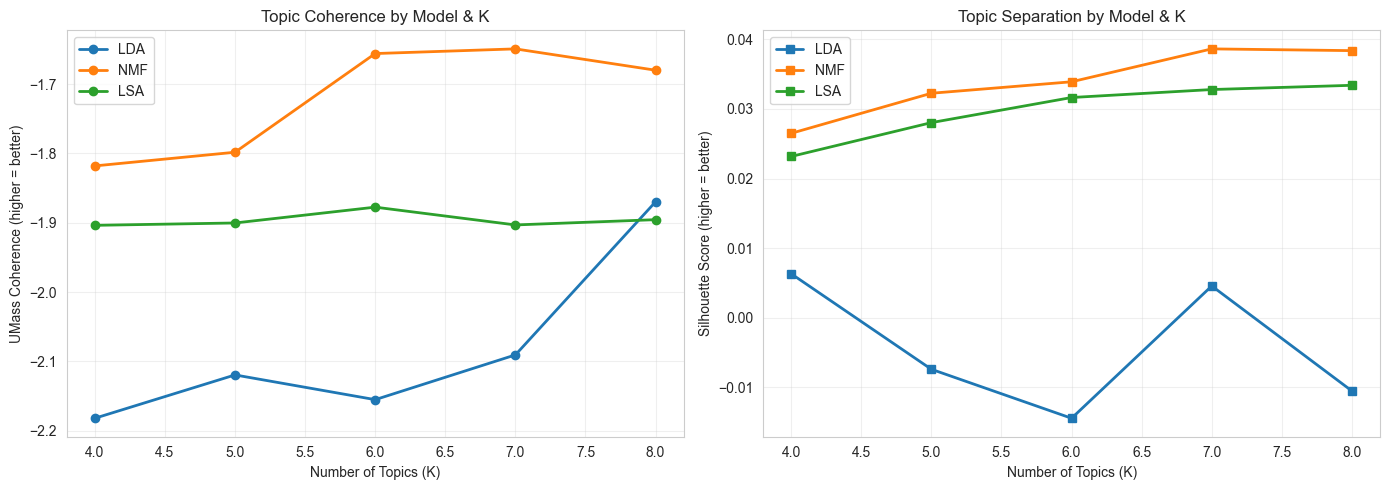

In [30]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coherence scores
for model_name in ['LDA', 'NMF', 'LSA']:
    subset = eval_df[eval_df['Model'] == model_name]
    axes[0].plot(subset['K'], subset['Coherence'], 'o-', label=model_name, linewidth=2)
axes[0].set_xlabel('Number of Topics (K)')
axes[0].set_ylabel('UMass Coherence (higher = better)')
axes[0].set_title('Topic Coherence by Model & K')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette scores
for model_name in ['LDA', 'NMF', 'LSA']:
    subset = eval_df[eval_df['Model'] == model_name]
    axes[1].plot(subset['K'], subset['Silhouette'], 's-', label=model_name, linewidth=2)
axes[1].set_xlabel('Number of Topics (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Topic Separation by Model & K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Select best model based on combined ranking of coherence + silhouette
# We rank each metric (higher = better) and pick the model with the best average rank

eval_df['Coherence_Rank'] = eval_df['Coherence'].rank(ascending=False)
eval_df['Silhouette_Rank'] = eval_df['Silhouette'].rank(ascending=False)
eval_df['Avg_Rank'] = (eval_df['Coherence_Rank'] + eval_df['Silhouette_Rank']) / 2

best_row = eval_df.loc[eval_df['Avg_Rank'].idxmin()]
best_model_key = f"{best_row['Model']}_k{int(best_row['K'])}"
best_k = int(best_row['K'])
best_model_type = best_row['Model']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_type} with K={best_k} topics")
print(f"  Coherence:  {best_row['Coherence']:.4f}")
print(f"  Silhouette: {best_row['Silhouette']:.4f}")
print(f"  Avg Rank:   {best_row['Avg_Rank']:.1f}")
print(f"{'='*60}")

# Rationale
print(f"\nRationale:")
print(f"  - We evaluated 3 algorithms × 5 topic counts = 15 configurations")
print(f"  - {best_model_type} at k={best_k} achieved the best combined ranking")
print(f"  - Coherence ensures topics are semantically meaningful (words co-occur)")
print(f"  - Silhouette ensures documents are cleanly assigned to distinct topics")
if best_model_type == 'NMF':
    print(f"  - NMF typically excels on short texts with TF-IDF (our case: avg ~10-15 tokens)")
elif best_model_type == 'LDA':
    print(f"  - LDA's probabilistic framework gives interpretable topic distributions")

best_topic_model = all_models[best_model_key]


BEST MODEL: NMF with K=7 topics
  Coherence:  -1.6492
  Silhouette: 0.0386
  Avg Rank:   1.0

Rationale:
  - We evaluated 3 algorithms × 5 topic counts = 15 configurations
  - NMF at k=7 achieved the best combined ranking
  - Coherence ensures topics are semantically meaningful (words co-occur)
  - Silhouette ensures documents are cleanly assigned to distinct topics
  - NMF typically excels on short texts with TF-IDF (our case: avg ~10-15 tokens)


## 7. Apply Best Topic Model & Label Topics

In [32]:
# Transform documents using the best model
if best_model_type == 'LDA':
    X_topics = best_topic_model.transform(X_count)
    feature_names = count_names
else:
    X_topics = best_topic_model.transform(X_tfidf)
    feature_names = tfidf_names

# Extract top words per topic for labeling
def get_topic_labels(model, feature_names, n_words=8):
    """Generate human-readable topic labels from top words."""
    labels = {}
    print(f"\n{'='*60}")
    print(f"TOPIC KEYWORDS ({best_model_type}, k={best_k})")
    print(f"{'='*60}")
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-n_words:][::-1]]
        # Use top 2-3 words as the label
        label = f"Topic {idx+1}: {' / '.join(top_words[:3])}"
        labels[idx] = label
        print(f"  {label}")
        print(f"    All keywords: {', '.join(top_words)}")
    return labels

topic_labels = get_topic_labels(best_topic_model, feature_names)

# Assign dominant topic to each document
df['Dominant_Topic'] = X_topics.argmax(axis=1)
df['Dominant_Topic_Label'] = df['Dominant_Topic'].map(topic_labels)
df['Topic_Confidence'] = X_topics.max(axis=1)  # How strongly the doc belongs to its topic

# Also store all topic probabilities for richer analysis
for i in range(best_k):
    df[f'Topic_{i}_Weight'] = X_topics[:, i]

print(f"\nTopic distribution across all documents:")
print(df['Dominant_Topic_Label'].value_counts())
print(f"\nMean topic confidence: {df['Topic_Confidence'].mean():.3f}")


TOPIC KEYWORDS (NMF, k=7)
  Topic 1: baat / mann baat / mann
    All keywords: baat, mann baat, mann, odisha, praise, highlight, crisis, baat urge
  Topic 2: sabha / rajya / rajya sabha
    All keywords: sabha, rajya, rajya sabha, speech, lok, lok sabha, sabha speech, economic
  Topic 3: west / west asia / asia
    All keywords: west, west asia, asia, crisis, asia crisis, amid, amid west, asia conflict
  Topic 4: indian / express / indian express
    All keywords: indian, express, indian express, chairman, parliament, poll, seek, democracy
  Topic 5: address / march / assam
    All keywords: address, march, assam, app, namo, namo app, via, via namo
  Topic 6: com / speech / call
    All keywords: com, speech, call, timesofindia, timesofindia indiatimes, indiatimes, indiatimes com, rally
  Topic 7: deccan / herald / deccan herald
    All keywords: deccan, herald, deccan herald, parliament, priyank, slam, karnataka, debate

Topic distribution across all documents:
Dominant_Topic_Label
T

In [33]:
# Topic distribution by speaker
topic_by_speaker = df.groupby(['Speaker', 'Dominant_Topic_Label']).size().reset_index(name='Count')
topic_by_speaker['Pct'] = topic_by_speaker.groupby('Speaker')['Count'].transform(lambda x: x / x.sum() * 100)

fig = px.bar(
    topic_by_speaker, x='Dominant_Topic_Label', y='Pct', color='Speaker',
    barmode='group', title='Topic Focus by Speaker (% of Articles)',
    labels={'Pct': '% of Articles', 'Dominant_Topic_Label': 'Topic'},
    color_discrete_map={'Modi': '#FF6B35', 'Kharge': '#004E89'}
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

## 8. Speaker Classification (Validation)

We train classifiers to predict the speaker from TF-IDF features. This serves as **validation** — if topics meaningfully differentiate speakers, classification should work well.

### Overfitting prevention:
- **Stratified 5-fold cross-validation** (not just train/test split)
- **Class-weight balancing** (Modi has 3.6x more articles than Kharge)
- **Regularization** in Logistic Regression and SVM
- **Max depth limit** in Random Forest

In [34]:
# Target variable
y = df['Speaker']

# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Class balance (train): {dict(y_train.value_counts())}")
print(f"Class balance (test):  {dict(y_test.value_counts())}")

# Define models with regularization to prevent overfitting
classifiers = {
    'Logistic Regression': LogisticRegression(
        C=1.0,                    # Regularization (lower = more regularization)
        class_weight='balanced',  # Handle class imbalance
        max_iter=1000,
        random_state=42
    ),
    'Linear SVM': LinearSVC(
        C=0.5,                    # Moderate regularization
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,             # Limit depth to prevent overfitting
        min_samples_leaf=5,       # Require minimum samples at leaf
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Naive Bayes': MultinomialNB(alpha=0.5),  # Smoothing parameter
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,              # Shallow trees = less overfitting
        learning_rate=0.1,
        subsample=0.8,            # Row subsampling
        random_state=42
    )
}

# Evaluate with cross-validation AND test set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_results = []

print(f"\n{'='*70}")
print(f"{'Model':<25} {'CV Acc (mean±std)':<22} {'Test Acc':<12} {'Overfit?'}")
print(f"{'='*70}")

best_clf_score = 0
best_clf = None
best_clf_name = ''

for name, clf in classifiers.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Fit on full training set, evaluate on test set
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    
    # Detect overfitting: if train acc >> test acc, it's overfitting
    overfit_gap = train_acc - test_acc
    overfit_flag = '⚠️ YES' if overfit_gap > 0.05 else '✓ No'
    
    print(f"  {name:<23} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}     {test_acc:.4f}       {overfit_flag} (gap={overfit_gap:.3f})")
    
    clf_results.append({
        'Model': name, 'CV_Mean': cv_scores.mean(), 'CV_Std': cv_scores.std(),
        'Test_Acc': test_acc, 'Train_Acc': train_acc, 'Overfit_Gap': overfit_gap
    })
    
    # Select best: prioritize CV score (more robust than single test split)
    # But penalize if overfitting
    adjusted_score = cv_scores.mean() - max(0, overfit_gap - 0.05) * 0.5
    if adjusted_score > best_clf_score:
        best_clf_score = adjusted_score
        best_clf = clf
        best_clf_name = name

print(f"\n✓ Best classifier: {best_clf_name}")

clf_results_df = pd.DataFrame(clf_results)

Train set: 330 samples
Test set:  83 samples
Class balance (train): {'Modi': np.int64(241), 'Kharge': np.int64(89)}
Class balance (test):  {'Modi': np.int64(61), 'Kharge': np.int64(22)}

Model                     CV Acc (mean±std)      Test Acc     Overfit?
  Logistic Regression     0.8788 ± 0.0303     0.9277       ✓ No (gap=0.036)
  Linear SVM              0.8727 ± 0.0366     0.9277       ⚠️ YES (gap=0.051)
  Random Forest           0.6879 ± 0.0485     0.7952       ✓ No (gap=0.005)
  Naive Bayes             0.8818 ± 0.0148     0.8916       ⚠️ YES (gap=0.069)
  Gradient Boosting       0.8242 ± 0.0435     0.8554       ⚠️ YES (gap=0.145)

✓ Best classifier: Logistic Regression



Classification Report (Logistic Regression):
              precision    recall  f1-score   support

      Kharge       0.83      0.91      0.87        22
        Modi       0.97      0.93      0.95        61

    accuracy                           0.93        83
   macro avg       0.90      0.92      0.91        83
weighted avg       0.93      0.93      0.93        83



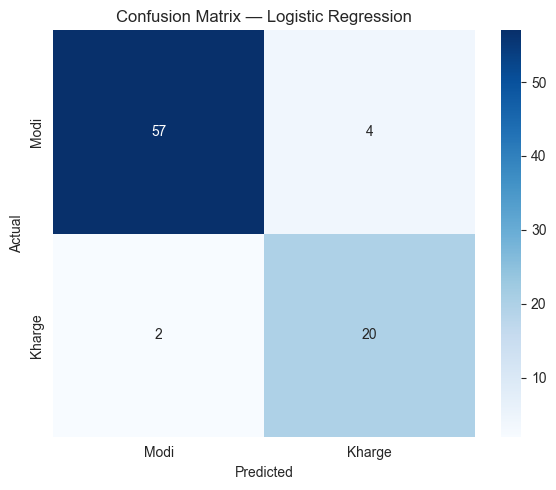

In [35]:
# Detailed classification report for best model
y_pred = best_clf.predict(X_test)
print(f"\nClassification Report ({best_clf_name}):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Modi', 'Kharge'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Modi', 'Kharge'],
            yticklabels=['Modi', 'Kharge'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Models

In [36]:
# Save the best topic model, vectorizers, and classifier
joblib.dump(best_topic_model, 'best_topic_model.pkl')
joblib.dump(tfidf_vec, 'tfidf_vectorizer.pkl')
joblib.dump(count_vec, 'count_vectorizer.pkl')
joblib.dump(best_clf, 'best_classifier.pkl')

# Save processed data for the dashboard
df.to_csv('processed_speeches.csv', index=False)

# Save evaluation results
eval_df.to_csv('topic_model_evaluation.csv', index=False)
clf_results_df.to_csv('classifier_evaluation.csv', index=False)

print("Saved:")
print("  - best_topic_model.pkl")
print("  - tfidf_vectorizer.pkl")
print("  - count_vectorizer.pkl")
print("  - best_classifier.pkl")
print("  - processed_speeches.csv")
print("  - topic_model_evaluation.csv")
print("  - classifier_evaluation.csv")

Saved:
  - best_topic_model.pkl
  - tfidf_vectorizer.pkl
  - count_vectorizer.pkl
  - best_classifier.pkl
  - processed_speeches.csv
  - topic_model_evaluation.csv
  - classifier_evaluation.csv


## 10. Venn Diagram — Topic Word Intersection

This shows which top TF-IDF terms are unique to each speaker vs. shared, revealing rhetorical overlap.

Modi-only terms (37): ['airport', 'amid', 'amid west', 'asia', 'asia conflict', 'asia crisis', 'assam', 'baat', 'bengal', 'challenge', 'citizen', 'concern', 'conflict', 'economic', 'energy']
Kharge-only terms (37): ['attack', 'bill', 'centre', 'chairman', 'complaint', 'court', 'day', 'deccan', 'deccan herald', 'demand', 'deve', 'deve gowda', 'expunged', 'govt', 'gowda']
Shared terms (13): ['address', 'call', 'com', 'crisis', 'express', 'indian', 'indian express', 'parliament', 'rajya', 'rajya sabha', 'sabha', 'sabha speech', 'speech']


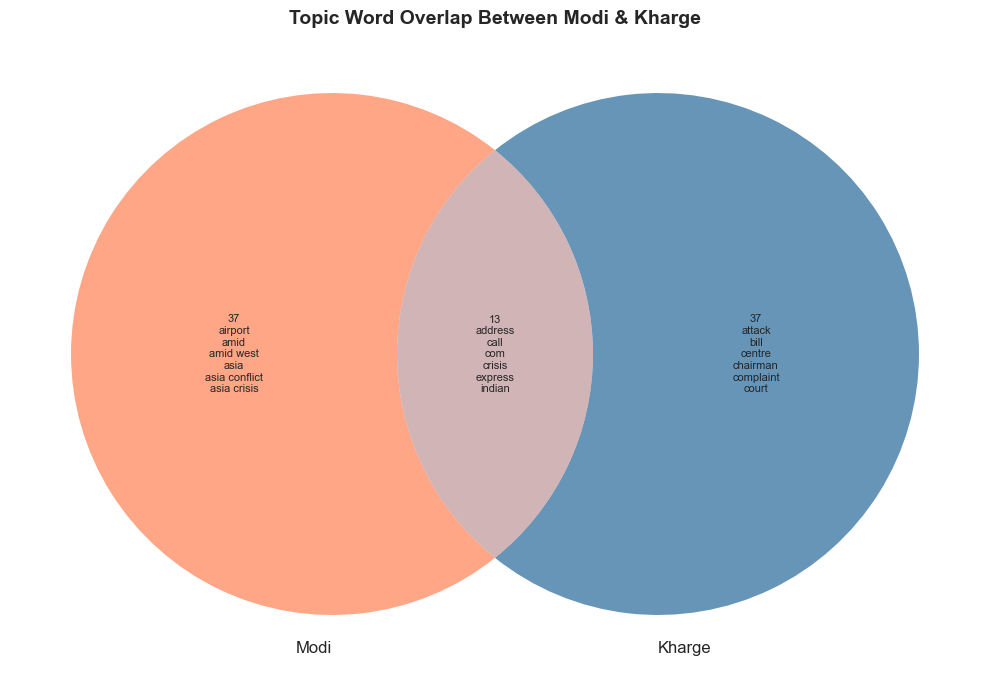

In [37]:
def get_speaker_top_words(speaker_df, top_n=50):
    """Get top TF-IDF words for a specific speaker's documents."""
    vec = TfidfVectorizer(max_df=0.85, min_df=2, max_features=1000, ngram_range=(1, 2))
    X = vec.fit_transform(speaker_df['Clean_Text'])
    scores = np.array(X.mean(axis=0)).flatten()
    top_idx = scores.argsort()[-top_n:][::-1]
    return set(vec.get_feature_names_out()[top_idx])

modi_df = df[df['Speaker'] == 'Modi']
kharge_df = df[df['Speaker'] == 'Kharge']

modi_words = get_speaker_top_words(modi_df, 50)
kharge_words = get_speaker_top_words(kharge_df, 50)

# Compute sets
shared_words = modi_words & kharge_words
modi_only = modi_words - kharge_words
kharge_only = kharge_words - modi_words

print(f"Modi-only terms ({len(modi_only)}): {sorted(modi_only)[:15]}")
print(f"Kharge-only terms ({len(kharge_only)}): {sorted(kharge_only)[:15]}")
print(f"Shared terms ({len(shared_words)}): {sorted(shared_words)[:15]}")

# Plot Venn diagram
fig, ax = plt.subplots(figsize=(10, 7))
v = venn2(
    [modi_words, kharge_words],
    set_labels=('Modi', 'Kharge'),
    set_colors=('#FF6B35', '#004E89'),
    alpha=0.6,
    ax=ax
)

# Add word annotations
if v.get_label_by_id('10'):
    v.get_label_by_id('10').set_text(f"{len(modi_only)}\n" + '\n'.join(sorted(modi_only)[:6]))
    v.get_label_by_id('10').set_fontsize(8)
if v.get_label_by_id('01'):
    v.get_label_by_id('01').set_text(f"{len(kharge_only)}\n" + '\n'.join(sorted(kharge_only)[:6]))
    v.get_label_by_id('01').set_fontsize(8)
if v.get_label_by_id('11'):
    v.get_label_by_id('11').set_text(f"{len(shared_words)}\n" + '\n'.join(sorted(shared_words)[:6]))
    v.get_label_by_id('11').set_fontsize(8)

ax.set_title('Topic Word Overlap Between Modi & Kharge', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('venn_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

# Save Venn data for dashboard
venn_data = {
    'modi_only': sorted(modi_only),
    'kharge_only': sorted(kharge_only),
    'shared': sorted(shared_words)
}
import json
with open('venn_data.json', 'w') as f:
    json.dump(venn_data, f)

## 11. Temporal Topic Evolution

In [38]:
# Topic evolution over time — stacked area charts per speaker
# For each month × speaker, compute average topic weight (not just dominant topic count)
# This gives a smoother, more accurate picture of topic mix

topic_weight_cols = [f'Topic_{i}_Weight' for i in range(best_k)]
temporal_weights = df.groupby(['YearMonth', 'Speaker'])[topic_weight_cols].mean().reset_index()

# Melt for plotting
temporal_melted = temporal_weights.melt(
    id_vars=['YearMonth', 'Speaker'],
    value_vars=topic_weight_cols,
    var_name='Topic', value_name='Avg_Weight'
)
temporal_melted['Topic_Label'] = temporal_melted['Topic'].apply(
    lambda x: topic_labels[int(x.split('_')[1])]
)

# Plot for each speaker
for speaker in ['Modi', 'Kharge']:
    speaker_data = temporal_melted[temporal_melted['Speaker'] == speaker]
    fig = px.area(
        speaker_data, x='YearMonth', y='Avg_Weight', color='Topic_Label',
        title=f'{speaker} — Topic Evolution Over Time (Avg. Weight)',
        labels={'Avg_Weight': 'Average Topic Weight', 'YearMonth': 'Month'},
        groupnorm='percent'  # Normalize to 100% to show proportional shifts
    )
    fig.update_layout(yaxis_title='Topic Share (%)', legend_title='Topic')
    fig.show()

In [39]:
# Side-by-side comparison: topic count by month
temporal_topics = df.groupby(['YearMonth', 'Speaker', 'Dominant_Topic_Label']).size().reset_index(name='Count')

fig = px.bar(
    temporal_topics, x='YearMonth', y='Count', color='Dominant_Topic_Label',
    facet_col='Speaker', barmode='stack',
    title='Topic Distribution Over Time by Speaker (Stacked)',
    labels={'Count': 'Number of Articles', 'YearMonth': 'Month', 'Dominant_Topic_Label': 'Topic'}
)
fig.update_layout(height=500)
fig.show()

## 12. Interactive Dashboard (Plotly Dash)

The dashboard provides:
1. **Overview tab** — Article volumes, topic distribution by speaker
2. **Topic Evolution tab** — Temporal trends with speaker filter
3. **Comparison tab** — Side-by-side speaker comparison, Venn diagram
4. **Model Performance tab** — Evaluation metrics for topic models and classifiers

Run the cell below, then open the URL printed (usually http://127.0.0.1:8050).

In [40]:
import dash
from dash import dcc, html, Input, Output
import dash_bootstrap_components as dbc
import json

# ── Load saved data ──────────────────────────────────────────────────
df_dash = pd.read_csv('processed_speeches.csv')
eval_dash = pd.read_csv('topic_model_evaluation.csv')
clf_dash = pd.read_csv('classifier_evaluation.csv')
with open('venn_data.json', 'r') as f:
    venn_data = json.load(f)

topic_weight_cols = [c for c in df_dash.columns if c.startswith('Topic_') and c.endswith('_Weight')]
n_topics = len(topic_weight_cols)

# Derive topic labels from data
unique_topics = sorted(df_dash['Dominant_Topic_Label'].unique())

# ── Color palette ────────────────────────────────────────────────────
MODI_COLOR = '#FF6B35'
KHARGE_COLOR = '#004E89'
SPEAKER_COLORS = {'Modi': MODI_COLOR, 'Kharge': KHARGE_COLOR}

# ── Encode Venn diagram image ────────────────────────────────────────
venn_img_b64 = ''
try:
    with open('venn_diagram.png', 'rb') as f:
        venn_img_b64 = base64.b64encode(f.read()).decode()
except FileNotFoundError:
    pass

# ── Pre-build static figures ─────────────────────────────────────────

# 1. Article volume over time
vol_data = df_dash.groupby(['YearMonth', 'Speaker']).size().reset_index(name='Count')
fig_volume = px.bar(
    vol_data, x='YearMonth', y='Count', color='Speaker', barmode='group',
    title='Article Volume Over Time',
    color_discrete_map=SPEAKER_COLORS
)
fig_volume.update_layout(template='plotly_white', xaxis_title='Month', yaxis_title='Articles')

# 2. Overall topic distribution
topic_dist = df_dash.groupby(['Speaker', 'Dominant_Topic_Label']).size().reset_index(name='Count')
topic_dist['Pct'] = topic_dist.groupby('Speaker')['Count'].transform(lambda x: x / x.sum() * 100)
fig_topic_dist = px.bar(
    topic_dist, x='Dominant_Topic_Label', y='Pct', color='Speaker', barmode='group',
    title='Topic Focus by Speaker (% of Articles)',
    color_discrete_map=SPEAKER_COLORS,
    labels={'Pct': '% of Articles', 'Dominant_Topic_Label': 'Topic'}
)
fig_topic_dist.update_layout(template='plotly_white', xaxis_tickangle=-25)

# 3. Model evaluation charts
fig_coherence = px.line(
    eval_dash, x='K', y='Coherence', color='Model', markers=True,
    title='Topic Coherence (UMass) — Higher is Better'
)
fig_coherence.update_layout(template='plotly_white')

fig_silhouette = px.line(
    eval_dash, x='K', y='Silhouette', color='Model', markers=True,
    title='Silhouette Score — Higher is Better'
)
fig_silhouette.update_layout(template='plotly_white')

# 4. Classifier comparison
fig_clf = go.Figure()
fig_clf.add_trace(go.Bar(
    name='CV Accuracy', x=clf_dash['Model'], y=clf_dash['CV_Mean'],
    error_y=dict(type='data', array=clf_dash['CV_Std']),
    marker_color='#2196F3'
))
fig_clf.add_trace(go.Bar(
    name='Test Accuracy', x=clf_dash['Model'], y=clf_dash['Test_Acc'],
    marker_color='#4CAF50'
))
fig_clf.update_layout(
    title='Classifier Performance (CV vs Test Accuracy)',
    barmode='group', template='plotly_white',
    yaxis_title='Accuracy', xaxis_title='Model'
)

# ── Dashboard Layout ─────────────────────────────────────────────────
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

# Summary stats
total_articles = len(df_dash)
modi_count = len(df_dash[df_dash['Speaker'] == 'Modi'])
kharge_count = len(df_dash[df_dash['Speaker'] == 'Kharge'])

summary_cards = dbc.Row([
    dbc.Col(dbc.Card(dbc.CardBody([
        html.H4(f"{total_articles}", className='text-center text-primary'),
        html.P('Total Articles', className='text-center text-muted')
    ]), className='shadow-sm'), width=3),
    dbc.Col(dbc.Card(dbc.CardBody([
        html.H4(f"{modi_count}", className='text-center', style={'color': MODI_COLOR}),
        html.P('Modi Articles', className='text-center text-muted')
    ]), className='shadow-sm'), width=3),
    dbc.Col(dbc.Card(dbc.CardBody([
        html.H4(f"{kharge_count}", className='text-center', style={'color': KHARGE_COLOR}),
        html.P('Kharge Articles', className='text-center text-muted')
    ]), className='shadow-sm'), width=3),
    dbc.Col(dbc.Card(dbc.CardBody([
        html.H4(f"{n_topics}", className='text-center text-success'),
        html.P('Topics Identified', className='text-center text-muted')
    ]), className='shadow-sm'), width=3),
], className='mb-4')

# Tabs
tab_overview = dbc.Tab(label='Overview', children=[
    html.Br(),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig_volume), width=6),
        dbc.Col(dcc.Graph(figure=fig_topic_dist), width=6),
    ])
])

tab_evolution = dbc.Tab(label='Topic Evolution', children=[
    html.Br(),
    dbc.Row([
        dbc.Col([
            html.Label('Select Speaker:', className='fw-bold'),
            dcc.Dropdown(
                id='speaker-dropdown',
                options=[{'label': s, 'value': s} for s in ['Modi', 'Kharge', 'Both']],
                value='Both', clearable=False
            )
        ], width=3),
        dbc.Col([
            html.Label('Chart Type:', className='fw-bold'),
            dcc.Dropdown(
                id='chart-type-dropdown',
                options=[
                    {'label': 'Stacked Area (% Share)', 'value': 'area'},
                    {'label': 'Stacked Bar (Count)', 'value': 'bar'},
                    {'label': 'Line (Weight Trend)', 'value': 'line'}
                ],
                value='area', clearable=False
            )
        ], width=3),
    ], className='mb-3'),
    dcc.Graph(id='evolution-chart')
])

tab_comparison = dbc.Tab(label='Speaker Comparison', children=[
    html.Br(),
    dbc.Row([
        dbc.Col([
            html.H5('Topic Word Overlap (Venn Diagram)', className='text-center'),
            html.Img(
                src=f'data:image/png;base64,{venn_img_b64}' if venn_img_b64 else '',
                style={'width': '100%', 'maxWidth': '600px', 'margin': 'auto', 'display': 'block'}
            ) if venn_img_b64 else html.P('Venn diagram not found. Run the Venn cell first.'),
        ], width=6),
        dbc.Col([
            html.H5('Word Set Details', className='text-center'),
            dbc.Card(dbc.CardBody([
                html.H6(f"Modi-Only ({len(venn_data.get('modi_only', []))} terms)", style={'color': MODI_COLOR}),
                html.P(', '.join(venn_data.get('modi_only', [])[:20]), style={'fontSize': '12px'}),
                html.Hr(),
                html.H6(f"Kharge-Only ({len(venn_data.get('kharge_only', []))} terms)", style={'color': KHARGE_COLOR}),
                html.P(', '.join(venn_data.get('kharge_only', [])[:20]), style={'fontSize': '12px'}),
                html.Hr(),
                html.H6(f"Shared ({len(venn_data.get('shared', []))} terms)", style={'color': '#666'}),
                html.P(', '.join(venn_data.get('shared', [])[:20]), style={'fontSize': '12px'}),
            ]), className='shadow-sm')
        ], width=6),
    ]),
    html.Br(),
    dbc.Row([
        dbc.Col([
            html.H5('Topic Heatmap: Speaker × Topic', className='text-center'),
            dcc.Graph(id='heatmap-chart')
        ])
    ])
])

tab_model = dbc.Tab(label='Model Performance', children=[
    html.Br(),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig_coherence), width=6),
        dbc.Col(dcc.Graph(figure=fig_silhouette), width=6),
    ]),
    html.Br(),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig_clf), width=8),
        dbc.Col([
            html.H5('Classifier Summary'),
            dbc.Table.from_dataframe(
                clf_dash[['Model', 'CV_Mean', 'Test_Acc', 'Overfit_Gap']].round(4),
                striped=True, bordered=True, hover=True, size='sm'
            )
        ], width=4)
    ])
])

project_details = html.Div(style={
    'backgroundColor': '#ffffff', 'borderRadius': '16px', 'padding': '32px', 'marginBottom': '32px',
    'marginTop': '10px', 'boxShadow': '0 10px 25px -5px rgba(0,0,0,0.05)', 'border': '1px solid #e2e8f0',
    'display': 'flex', 'flexWrap': 'wrap', 'gap': '32px', 'alignItems': 'center'
}, children=[
    html.Div(style={'flex': '0 0 auto', 'textAlign': 'center'}, children=[
        html.Img(src='https://upload.wikimedia.org/wikipedia/en/d/d3/BITS_Pilani-Logo.svg', style={'width': '140px', 'height': 'auto'})
    ]),
    html.Div(style={'flex': '1', 'minWidth': '300px'}, children=[
        html.H2('Birla Institute of Technology and Science, Pilani', style={'fontSize': '1.8rem', 'color': '#1e3a8a', 'marginBottom': '4px', 'fontWeight': '700'}),
        html.H3('Pilani Campus', style={'fontSize': '1.2rem', 'color': '#64748b', 'fontWeight': 'bold', 'marginBottom': '16px'}),
        html.P('Submitted By: Group 15', style={'marginBottom': '12px', 'fontWeight': '600', 'color': '#1e293b'}),
        html.Div(style={'overflowX': 'auto', 'backgroundColor': '#f1f5f9', 'borderRadius': '10px', 'padding': '2px'}, children=[
            html.Table(style={'width': '100%', 'borderCollapse': 'collapse', 'backgroundColor': '#fff', 'borderRadius': '8px', 'overflow': 'hidden'}, children=[
                html.Thead(html.Tr([
                    html.Th('Name', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'backgroundColor': '#e2e8f0', 'color': '#334155', 'fontWeight': '600', 'fontSize': '0.9rem', 'textTransform': 'uppercase', 'letterSpacing': '0.5px'}),
                    html.Th('BITS ID', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'backgroundColor': '#e2e8f0', 'color': '#334155', 'fontWeight': '600', 'fontSize': '0.9rem', 'textTransform': 'uppercase', 'letterSpacing': '0.5px'})
                ])),
                html.Tbody([
                    html.Tr([html.Td('Priyanka Chitlangia', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'}), html.Td('2025H1540818P', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'})]),
                    html.Tr([html.Td('Subodh Sanjay Joshi', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'}), html.Td('2025H1540833P', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'})]),
                    html.Tr([html.Td('Harsh Jain', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'}), html.Td('2025H1540837P', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': '1px solid #e2e8f0', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'})]),
                    html.Tr([html.Td('Aman Tanwar', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': 'none', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'}), html.Td('2025H1540838P', style={'padding': '12px 20px', 'textAlign': 'left', 'borderBottom': 'none', 'fontSize': '0.95rem', 'fontWeight': '500', 'color': '#1e293b'})])
                ])
            ])
        ])
    ])
])

app.layout = dbc.Container([
    html.H2('Political Speeches — Topic Analysis Dashboard',
            className='text-center my-4', style={'fontWeight': 'bold'}),
    project_details,
    html.P('Comparing discourse themes of Modi and Kharge across time using NLP topic modeling.',
           className='text-center text-muted mb-4'),
    summary_cards,
    dbc.Tabs([tab_overview, tab_evolution, tab_comparison, tab_model])
], fluid=True)

# ── Callbacks ─────────────────────────────────────────────────────────

@app.callback(
    Output('evolution-chart', 'figure'),
    [Input('speaker-dropdown', 'value'),
     Input('chart-type-dropdown', 'value')]
)
def update_evolution(speaker, chart_type):
    # Filter data
    if speaker == 'Both':
        data = df_dash.copy()
    else:
        data = df_dash[df_dash['Speaker'] == speaker].copy()
    
    if chart_type == 'area':
        # Average topic weights over time
        tw = data.groupby(['YearMonth', 'Speaker'])[topic_weight_cols].mean().reset_index()
        tw_melted = tw.melt(
            id_vars=['YearMonth', 'Speaker'], value_vars=topic_weight_cols,
            var_name='Topic', value_name='Weight'
        )
        tw_melted['Topic'] = tw_melted['Topic'].apply(
            lambda x: unique_topics[int(x.split('_')[1])] if int(x.split('_')[1]) < len(unique_topics) else x
        )
        
        if speaker == 'Both':
            fig = px.area(
                tw_melted, x='YearMonth', y='Weight', color='Topic',
                facet_col='Speaker', groupnorm='percent',
                title='Topic Evolution (Proportional Share)'
            )
        else:
            fig = px.area(
                tw_melted, x='YearMonth', y='Weight', color='Topic',
                groupnorm='percent',
                title=f'{speaker} — Topic Evolution (Proportional Share)'
            )
    elif chart_type == 'bar':
        counts = data.groupby(['YearMonth', 'Speaker', 'Dominant_Topic_Label']).size().reset_index(name='Count')
        if speaker == 'Both':
            fig = px.bar(
                counts, x='YearMonth', y='Count', color='Dominant_Topic_Label',
                facet_col='Speaker', barmode='stack',
                title='Topic Counts Over Time (Stacked)'
            )
        else:
            fig = px.bar(
                counts, x='YearMonth', y='Count', color='Dominant_Topic_Label',
                barmode='stack',
                title=f'{speaker} — Topic Counts Over Time'
            )
    else:  # line
        tw = data.groupby(['YearMonth', 'Speaker'])[topic_weight_cols].mean().reset_index()
        tw_melted = tw.melt(
            id_vars=['YearMonth', 'Speaker'], value_vars=topic_weight_cols,
            var_name='Topic', value_name='Weight'
        )
        tw_melted['Topic'] = tw_melted['Topic'].apply(
            lambda x: unique_topics[int(x.split('_')[1])] if int(x.split('_')[1]) < len(unique_topics) else x
        )
        
        if speaker == 'Both':
            fig = px.line(
                tw_melted, x='YearMonth', y='Weight', color='Topic',
                facet_col='Speaker', markers=True,
                title='Topic Weight Trends'
            )
        else:
            fig = px.line(
                tw_melted, x='YearMonth', y='Weight', color='Topic',
                markers=True,
                title=f'{speaker} — Topic Weight Trends'
            )
    
    fig.update_layout(template='plotly_white', height=500)
    return fig


@app.callback(
    Output('heatmap-chart', 'figure'),
    Input('speaker-dropdown', 'value')  # Re-use speaker filter
)
def update_heatmap(_):
    # Heatmap: avg topic weight per speaker
    heatmap_data = df_dash.groupby('Speaker')[topic_weight_cols].mean()
    heatmap_data.columns = [unique_topics[int(c.split('_')[1])] if int(c.split('_')[1]) < len(unique_topics) else c for c in heatmap_data.columns]
    
    fig = px.imshow(
        heatmap_data.values,
        x=heatmap_data.columns.tolist(),
        y=heatmap_data.index.tolist(),
        color_continuous_scale='RdYlBu_r',
        title='Average Topic Affinity by Speaker',
        labels={'color': 'Avg Weight'}
    )
    fig.update_layout(template='plotly_white', height=350)
    return fig

# ── Run ────────────────────────────────────────────────────────────────
print("Starting dashboard...")
print("Open http://127.0.0.1:8050 in your browser.")
app.run(debug=False, port=8050)



Starting dashboard...
Open http://127.0.0.1:8050 in your browser.
